In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import anndata as ad
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import adjusted_rand_score
import seaborn as sns
ad.settings.allow_write_nullable_strings = True
#from scipy.stats import bootstrap
sc.settings.verbosity = 0


In [ ]:
def load_evidence(h5ad_path):

    # Loads the PCA artifact from P05 file
    print(f"   -> Loading PCA artifact from: {h5ad_path}")
    adata = sc.read_h5ad(h5ad_path)
    print(f"   -> Loaded dimensions: {adata.n_obs} cells x {adata.n_vars} genes")
    abs = adata.var_names
    return adata,abs

In [ ]:
def split_data(adata):
    A_data_indices, B_data_indices = train_test_split(adata.obs_names,test_size=0.5,
                                                     random_state=42,shuffle=True)
    adata_A = adata[A_data_indices].copy()
    adata_B = adata[B_data_indices].copy()
    return adata_A,adata_B


In [ ]:
def stability_audit(adata_A):

    print("   -> INITIATING FORENSIC STABILITY AUDIT...")
    adata_A_test_1 = adata_A.copy()
    adata_A_test_2 = adata_A.copy()
    # ---------------------------------------------------------
    # TEST 1: PARAMETER STABILITY (The Resolution Sweep)
    # ---------------------------------------------------------
    print("   -> [TEST 1] Resolution Sweep (0.2 to 2.0)...")
    resolutions = np.arange(0.1,2.1,0.03).tolist()
    results = []
    sc.pp.neighbors(adata_A_test_1,n_neighbors = 15,n_pcs=10,method='umap',
                    knn=True,metric='euclidean',random_state=42)
    # Run Clustering at all resolutions
    for res in resolutions:
        key = f"leiden_res_{res}"
        sc.tl.leiden(adata_A_test_1, resolution=res, key_added=key, flavor='leidenalg')
        # Store count
        n_clusters = len(adata_A_test_1.obs[key].unique())
        results.append({'res': res, 'n_clusters': n_clusters, 'key': key})
    
    # Compute ARI between NEIGHBORS (The Plateau Check)
    df_res = pd.DataFrame(results)
    aris = [0.0] # First one has no previous neighbor
    for i in range(1, len(df_res)):
        prev_key = df_res.iloc[i-1]['key']
        curr_key = df_res.iloc[i]['key']
        # PHYSICS: Compare N vs N-1
        score = adjusted_rand_score(adata_A_test_1.obs[prev_key],
                                     adata_A_test_1.obs[curr_key])
        aris.append(score)
    
    df_res['neighbor_ari'] = aris
    
    # VISUALIZE THE PLATEAU
    plt.figure(figsize=(25, 13))
    sns.lineplot(data=df_res, x='res', y='n_clusters', marker='o', label='Cluster Count')
    ax2 = plt.twinx()
    sns.lineplot(data=df_res, x='res', y='neighbor_ari',
                  color='red', marker='x', ax=ax2, 
                  label='Stability (ARI)') # type: ignore
    plt.title("Parameter Stability: Look for High ARI + Flat Cluster Count")
    plt.savefig("/Users/qgem/GitHub/PBMC3k-reproducible/notebooks/" \
    "figures/stability_resolution_sweep.png")
    plt.close()
    

    # ---------------------------------------------------------
    # TEST 2: STRUCTURAL STABILITY (The Subsampling Shake)
    # ---------------------------------------------------------
    print("   -> [TEST 2] Subsampling Earthquake (80% Retention)...")
    
    # 1. Pick a reference resolution (e.g., 1.375 or whatever the sweep suggests)
    ref_res = 1.475
    # Ensure reference exists
    if f'leiden_res_{ref_res}' not in adata_A_test_1.obs:
        sc.tl.leiden(adata_A_test_1, resolution=ref_res,
                      key_added=f'leiden_res_{ref_res}', flavor='leidenalg')
    
    # 2. The Shake (Subsample 80%)
    # We use sc.pp.subsample to get a NEW object
    A_data_test_sub_indices, B_data_test_sub_indices = train_test_split(
        adata_A_test_2.obs_names,test_size=0.2,random_state=42,shuffle=True)
    adata_A_test_sub = adata_A_test_2[A_data_test_sub_indices].copy()
    
    # 3. The Re-Build (Must re-run Neighbors to be valid!)
    sc.pp.neighbors(adata_A_test_sub, n_neighbors=15, n_pcs=10, use_rep='X_pca')
    sc.tl.leiden(adata_A_test_sub, resolution=ref_res, key_added='leiden_sub', 
                 flavor='leidenalg')
    
    # 4. The Comparison (Intersecting Indices)
    # We compare the Original Label (in adata) vs New Label (in adata_sub) 
    # for the same cells
    original_labels = adata_A_test_1.obs.loc[adata_A_test_sub.obs_names,
                                              f'leiden_res_{ref_res}']
    new_labels = adata_A_test_sub.obs['leiden_sub']
    
    robustness_score = adjusted_rand_score(original_labels, new_labels)
    print(f"   -> Structural Robustness Score (ARI): {robustness_score:.3f}")
    
    if robustness_score < 0.7:
        print("    ⚠️ WARNING: Clusters are unstable! They collapsed under subsampling.")
    else:
        print("    ✅ PASSED: Clusters are physically robust.")

    # ---------------------------------------------------------
    # TEST 3: BIOLOGICAL SANITY CHECK (The Identity Verification)
    # ---------------------------------------------------------
    ref_res = 0.6
    print(f"   -> [TEST 3] Biological Sanity Check (at Res {ref_res})...")
    # Ensure reference exists
    if f'leiden_res_{ref_res}' not in adata_A_test_1.obs:
        sc.tl.leiden(adata_A_test_1, resolution=ref_res,
                      key_added=f'leiden_res_{ref_res}', flavor='leidenalg')
    
    # A. Quick Rank Genes (Wilcoxon is standard, t-test is faster for audit)
    # Physics: We ask "What makes Cluster X different from the rest?"
    sc.tl.rank_genes_groups(adata_A_test_1, groupby=f'leiden_res_{ref_res}',
                             method='wilcoxon')
    
    # B. Print Top 3 Markers per Cluster
    print("      -> Top 3 Marker Genes per Cluster:")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    # Extract results structure
    result_df = pd.DataFrame(adata_A_test_1.uns['rank_genes_groups']['names']).head(3)
    print(result_df)
    
    # C. VISUAL SANITY: The Canonical Marker DotPlot
    # These are the "Known Truths" for PBMC. If clusters don't light up 
    # correctly, the resolution is wrong.
    marker_genes_dict = {
        'B-cell': ['MS4A1', 'CD79A'],
        'T-cell': ['CD3D', 'IL7R', 'CD8A'],
        'NK': ['GNLY', 'NKG7'],
        'Mono': ['CD14', 'FCGR3A'],
        'Dendritic': ['FCER1A', 'CST3'],
        'Platelet': ['PPBP']
    }
    
    # Filter markers to ensure they exist in the dataset (prevent errors)
    valid_markers = {k: [g for g in v if g in adata_A_test_1.var_names] 
                     for k, v in marker_genes_dict.items()}
    
    print("      -> Generating Sanity DotPlot...")
    dp = sc.pl.dotplot(adata_A_test_1, valid_markers, groupby=f'leiden_res_{ref_res}',
                        standard_scale='var', show=False)
    plt.savefig("/Users/qgem/GitHub/PBMC3k-reproducible/notebooks/figures/" \
    "stability_biological_sanity.png")
    plt.close()


    a = adata_A_test_1.obs
    del adata_A_test_1,adata_A_test_sub,adata_A_test_2
    return df_res,a,result_df,valid_markers

  

In [ ]:
def knn_clustering_umap(adata_A,leiden_resolution:float, n_neighbors:int,n_pcs:int):
    
    sc.pp.neighbors(adata_A,n_neighbors = n_neighbors,n_pcs=n_pcs,method='umap',
                    knn=True,metric='euclidean',random_state=42)
    sc.tl.leiden(adata_A,resolution=leiden_resolution,n_iterations= -1,
                 flavor='leidenalg',random_state=42)
    #sc.tl.paga(adata_A,groups='leiden')
    #sc.pl.paga(adata_A)
    sc.tl.umap(adata_A,maxiter=500,random_state=42)
               #spread = 3.5,init_pos='paga',min_dist=0.001,)
    sc.pl.umap(adata_A,color='leiden')
    return adata_A


In [ ]:
def project_B_on_A(adata_B,adata_A):
    sc.tl.ingest(adata_B,adata_A,obs='leiden',embedding_method='umap')
    return adata_B


In [ ]:
def visualize_split(adata_A,adata_B):
    
    sc.pl.umap(adata_A,color='leiden',components ='all',
               size= 15.0,color_map = 'Blues',show=True,
               title = 'Training Manifold',legend_loc = 'on data',
               legend_fontsize = 'x-small',legend_fontweight = 'bold',
               legend_fontoutline = 3, )
    
    sc.pl.umap(adata_B,color='leiden',components ='all',
               size= 15.0,color_map = 'Blues',show=True,
               title = 'Projected Validation',legend_loc = 'on data',
               legend_fontsize = 'x-small',legend_fontweight = 'bold',
               legend_fontoutline = 3)
    

   -> Loading PCA artifact from: /Users/qgem/GitHub/PBMC3k-reproducible/data/objects/pbmc3k_pca.h5ad
   -> Loaded dimensions: 2536 cells x 13456 genes


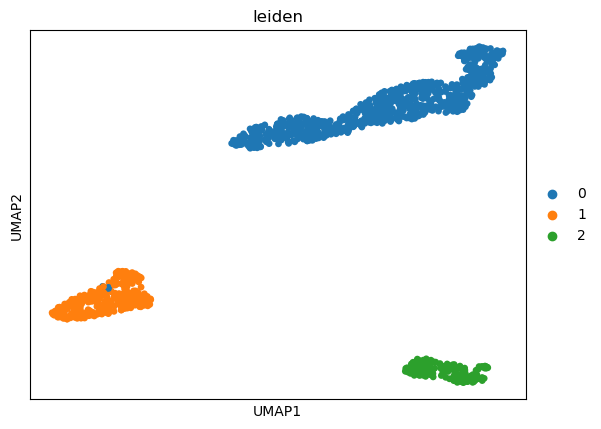

In [31]:
if __name__ == '__main__':
    h5ad_path = "/Users/qgem/GitHub/PBMC3k-reproducible/data/objects/pbmc3k_pca.h5ad"
    adata,abs = load_evidence(h5ad_path)
    adata_A, adata_B = split_data(adata)
    #def_res,a,result_df,valid_markers = stability_audit(adata_A)
    adata_A = knn_clustering_umap(adata_A,0.05,15,10)
    #adata_B = project_B_on_A(adata_B,adata_A)
    #visualize_split(adata_A,adata_B)
    a = adata_A.obs.groupby('leiden').groups
    b = pd.Series(a)


    


    visualize_split(adata_A,adata_B)
    df = pd.DataFrame(abs)
    sc.pl.umap(adata_A,color='CST3', layer='log1p_norm')
    sc.pl.umap(adata_A,color='LGALS2', layer='log1p_norm')
    sc.pl.umap(adata_A,color='S100A8', layer='log1p_norm')
    adata_subset = adata_A[adata_A.obs['leiden'].isin(['3', '5'])].copy()
    sc.pp.neighbors(adata_subset,n_neighbors = 10,n_pcs=10,method='umap',
                    knn=True,metric='euclidean',random_state=42)
    sc.tl.paga(adata_subset)
    sc.pl.paga(adata_subset)
    sc.tl.umap(adata_subset,min_dist=0.1,maxiter=500,random_state=42,
               spread = 3.5,init_pos='paga')
    sc.pl.umap(adata_subset, color='leiden')
    sc.pl.umap(adata_subset,color='CST3', layer='log1p_norm')
    sc.pl.umap(adata_subset,color='LGALS2', layer='log1p_norm')
    sc.pl.umap(adata_subset,color='S100A8', layer='log1p_norm')